# Notebook 03: Entrenamiento y Evaluación del Modelo

**Entrada:** `dataset.csv` (1,310 proteínas, 24 features, label)  
**Salida:** `model.pkl` (modelo entrenado listo para la app)

## Objetivos
1. Preparar los datos para el entrenamiento
2. Entrenar un clasificador **Random Forest** con validación cruzada estratificada
3. Comparar contra dos baselines: clasificador de mayoría y Logistic Regression
4. Analizar la importancia de features
5. Guardar el modelo final

## Decisiones de diseño
- **`class_weight='balanced'`** para compensar el desbalance 7:1
- **Cross-validation estratificada k=5** para respetar la proporción de clases en cada fold
- **Métricas principales**: AUC-ROC y F1-score (más informativas que accuracy con desbalance)
- **Sin escalado de features**: Random Forest no lo necesita (es invariante a escala)

## 0. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Rutas del proyecto — relativas a la carpeta notebooks/
PROJECT_ROOT = Path('..').resolve()
DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'dataset.csv'
MODEL_PATH   = PROJECT_ROOT / 'models' / 'model.pkl'

print(f"Entrada: {DATASET_PATH}")
print(f"Salida:  {MODEL_PATH}")
print("Librerías cargadas correctamente.")

Entrada: /home/apa/Documentos/github/antigen_predictor/data/processed/dataset.csv
Salida:  /home/apa/Documentos/github/antigen_predictor/models/model.pkl
Librerías cargadas correctamente.


## 1. Cargar dataset y preparar X, y

In [2]:
dataset = pd.read_csv(DATASET_PATH)
print(f"Dataset cargado: {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas")
print(f"Distribución de labels: {dataset['label'].value_counts().to_dict()}")

# Columnas de features
AMINO_ACIDS  = list('ACDEFGHIKLMNPQRSTVWY')
FEATURE_COLS = ['length', 'molecular_weight', 'isoelectric_point', 'gravy'] + \
               [f'aa_{aa}' for aa in AMINO_ACIDS]
META_COLS    = ['protein_id', 'source_molecule', 'source_molecule_iri', 'pathogen']

X = dataset[FEATURE_COLS].values
y = dataset['label'].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {FEATURE_COLS}")

Dataset cargado: 1,310 filas × 29 columnas
Distribución de labels: {1: 1149, 0: 161}

X shape: (1310, 24)
y shape: (1310,)
Features: ['length', 'molecular_weight', 'isoelectric_point', 'gravy', 'aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F', 'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L', 'aa_M', 'aa_N', 'aa_P', 'aa_Q', 'aa_R', 'aa_S', 'aa_T', 'aa_V', 'aa_W', 'aa_Y']


## 2. Definir modelos y esquema de validación

Usamos **Stratified K-Fold con k=5**: divide el dataset en 5 partes
manteniendo la proporción de clases en cada fold.
El modelo se entrena 5 veces, cada vez con un fold distinto como test.
Las métricas finales son la media y desviación estándar de los 5 folds.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Mayoría (baseline)': DummyClassifier(
        strategy='most_frequent'
    ),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
}

print("Modelos definidos:")
for name in models:
    print(f"  - {name}")
print(f"\nValidación: StratifiedKFold k=5, random_state=42")

Modelos definidos:
  - Mayoría (baseline)
  - Logistic Regression
  - Random Forest

Validación: StratifiedKFold k=5, random_state=42


## 3. Evaluación con cross-validation

Evaluamos los tres modelos con las mismas métricas y el mismo esquema de validación
para que los resultados sean comparables.

In [4]:
scoring = ['roc_auc', 'f1', 'f1_macro', 'accuracy']
cv_results = {}

for name, model in models.items():
    print(f"Evaluando: {name}...")
    results = cross_validate(
        model, X, y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    cv_results[name] = results
    print(f"  AUC-ROC: {results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}")
    print(f"  F1:      {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")

print("\nEvaluación completada.")

Evaluando: Mayoría (baseline)...
  AUC-ROC: 0.500 ± 0.000
  F1:      0.935 ± 0.001
Evaluando: Logistic Regression...
  AUC-ROC: 0.626 ± 0.043
  F1:      0.795 ± 0.026
Evaluando: Random Forest...
  AUC-ROC: 0.719 ± 0.050
  F1:      0.935 ± 0.004

Evaluación completada.


In [5]:
# Tabla resumen de resultados
summary = []
for name, results in cv_results.items():
    summary.append({
        'Modelo': name,
        'AUC-ROC': f"{results['test_roc_auc'].mean():.3f} ± {results['test_roc_auc'].std():.3f}",
        'F1':      f"{results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}",
        'F1-macro':f"{results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}",
        'Accuracy':f"{results['test_accuracy'].mean():.3f} ± {results['test_accuracy'].std():.3f}",
    })

df_summary = pd.DataFrame(summary).set_index('Modelo')
print("Comparativa de modelos (media ± std sobre 5 folds):")
df_summary

Comparativa de modelos (media ± std sobre 5 folds):


,AUC-ROC,F1,F1-macro,Accuracy
Modelo,,,,
Mayoría (baseline),0.500 ± 0.000,0.935 ± 0.001,0.467 ± 0.000,0.877 ± 0.002
Logistic Regression,0.626 ± 0.043,0.795 ± 0.026,0.523 ± 0.025,0.679 ± 0.032
Random Forest,0.719 ± 0.050,0.935 ± 0.004,0.618 ± 0.036,0.881 ± 0.008


## 4. Análisis detallado del Random Forest

Entrenamos el Random Forest sobre todo el dataset para obtener
las **curvas ROC por fold** y la **importancia de features**.

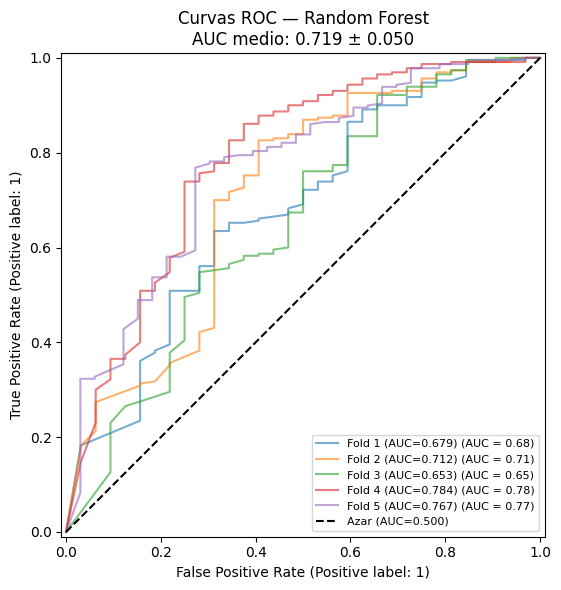

In [6]:
# Curvas ROC por fold
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 6))
auc_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores.append(auc)

    RocCurveDisplay.from_predictions(
        y_test, y_prob,
        name=f"Fold {fold+1} (AUC={auc:.3f})",
        ax=ax, alpha=0.6
    )

ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.500)')
ax.set_title(f'Curvas ROC — Random Forest\nAUC medio: {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}',
             fontsize=12)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print(f"AUC por fold: {[f'{a:.3f}' for a in auc_scores]}")
print(f"AUC medio:    {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

AUC por fold: ['0.679', '0.712', '0.653', '0.784', '0.767']
AUC medio:    0.719 ± 0.050


In [ ]:
# Matriz de confusión — fold 5 (último fold del bucle anterior, ejemplo representativo)
# Las métricas promediadas sobre todos los folds están en la tabla de §3.
y_pred = rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No antigénica (0)', 'Antigénica (1)'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matriz de confusión (fold 5)', fontsize=12)

print('\nClassification report (fold 5 — ejemplo representativo):')
print(classification_report(y_test, y_pred,
      target_names=['No antigénica (0)', 'Antigénica (1)']))

plt.tight_layout()
plt.show()


Classification report (fold 5 — ejemplo representativo):
                   precision    recall  f1-score   support

No antigénica (0)       0.64      0.27      0.38        33
   Antigénica (1)       0.90      0.98      0.94       229

         accuracy                           0.89       262
        macro avg       0.77      0.63      0.66       262
     weighted avg       0.87      0.89      0.87       262


## 5. Importancia de features

Random Forest calcula automáticamente la importancia de cada feature
basándose en cuánto contribuye cada una a reducir la impureza en los árboles.
Esto nos dice qué características fisicoquímicas son más relevantes
para predecir la antigenicidad.

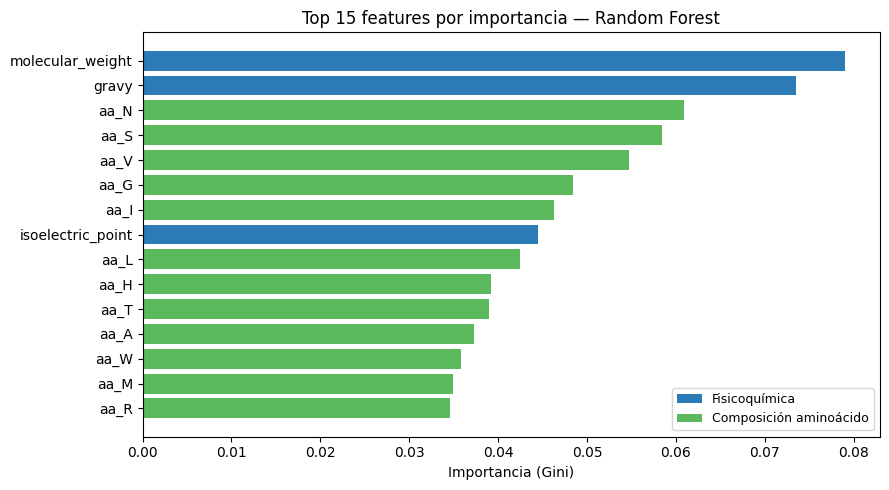

In [10]:
# Entrenar sobre todo el dataset para importancia de features
rf_full = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X, y)

importances = pd.Series(rf_full.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

# Top 15 features
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2c7bb6' if not f.startswith('aa_') else '#5cb85c' for f in top15.index]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top 15 features por importancia — Random Forest', fontsize=12)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c7bb6', label='Fisicoquímica'),
    Patch(facecolor='#5cb85c', label='Composición aminoácido')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'models' / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("Top 15 features:")
for feat, imp in top15.items():
    print(f"  {feat:<25} {imp:.4f}")

Top 15 features:
  molecular_weight          0.0790
  gravy                     0.0735
  aa_N                      0.0609
  aa_S                      0.0584
  aa_V                      0.0548
  aa_G                      0.0484
  aa_I                      0.0463
  isoelectric_point         0.0444
  aa_L                      0.0425
  aa_H                      0.0392
  aa_T                      0.0389
  aa_A                      0.0373
  aa_W                      0.0358
  aa_M                      0.0349
  aa_R                      0.0346


In [12]:
# Importancia acumulada por grupo de features
fisico_imp = importances[['length', 'molecular_weight', 'isoelectric_point', 'gravy']].sum()
aa_imp     = importances[[f for f in FEATURE_COLS if f.startswith('aa_')]].sum()

print("Importancia acumulada por grupo:")
print(f"  Features fisicoquímicas (4):  {fisico_imp:.4f} ({fisico_imp:.1%})")
print(f"  Composición aminoácidos (20): {aa_imp:.4f} ({aa_imp:.1%})")

Importancia acumulada por grupo:
  Features fisicoquímicas (4):  0.2199 (22.0%)
  Composición aminoácidos (20): 0.7801 (78.0%)


## 6. Guardar el modelo final

Guardamos el modelo entrenado sobre **todo el dataset** (`rf_full`).
Este es el modelo que cargará la app de Streamlit para hacer predicciones.

In [13]:
# Guardamos el modelo junto con los metadatos necesarios para la app
model_bundle = {
    'model':        rf_full,
    'feature_cols': FEATURE_COLS,
    'amino_acids':  AMINO_ACIDS,
    'label_map':    {0: 'No antigénica', 1: 'Antigénica'},
    'n_train':      len(X),
    'auc_cv':       np.mean(auc_scores),
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"Modelo guardado en: {MODEL_PATH}")
print(f"Contenido del bundle:")
for k, v in model_bundle.items():
    print(f"  {k}: {type(v).__name__}")

Modelo guardado en: /home/apa/Documentos/github/antigen_predictor/models/model.pkl
Contenido del bundle:
  model: RandomForestClassifier
  feature_cols: list
  amino_acids: list
  label_map: dict
  n_train: int
  auc_cv: float64


## 7. Resumen final

Completa esta celda con los valores reales tras ejecutar el notebook.

In [14]:
rf_auc  = cv_results['Random Forest']['test_roc_auc']
rf_f1   = cv_results['Random Forest']['test_f1']
lr_auc  = cv_results['Logistic Regression']['test_roc_auc']
dum_auc = cv_results['Mayoría (baseline)']['test_roc_auc']

print("=" * 55)
print("RESUMEN DE RESULTADOS")
print("=" * 55)
print(f"  Dataset: {len(X):,} proteínas, {X.shape[1]} features")
print(f"  Validación: StratifiedKFold k=5")
print()
print(f"  {'Modelo':<25} {'AUC-ROC':>10} {'F1':>10}")
print(f"  {'-'*47}")
print(f"  {'Mayoría (baseline)':<25} {dum_auc.mean():>10.3f} {'N/A':>10}")
print(f"  {'Logistic Regression':<25} {lr_auc.mean():>10.3f} {cv_results['Logistic Regression']['test_f1'].mean():>10.3f}")
print(f"  {'Random Forest':<25} {rf_auc.mean():>10.3f} {rf_f1.mean():>10.3f}")
print("=" * 55)
print(f"\n  Mejora RF vs baseline: +{rf_auc.mean() - dum_auc.mean():.3f} AUC-ROC")
print(f"  Modelo guardado en: model.pkl")
print(f"  Listo para Notebook 04 (app Streamlit)")

RESUMEN DE RESULTADOS
  Dataset: 1,310 proteínas, 24 features
  Validación: StratifiedKFold k=5

  Modelo                       AUC-ROC         F1
  -----------------------------------------------
  Mayoría (baseline)             0.500        N/A
  Logistic Regression            0.626      0.795
  Random Forest                  0.719      0.935

  Mejora RF vs baseline: +0.219 AUC-ROC
  Modelo guardado en: model.pkl
  Listo para Notebook 04 (app Streamlit)
